# STUDENT PASS/FAIL PREDICTION STUDENT PASS/FAIL PREDICTION 



# 1. Import Required Libraries

In [26]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Data splitting
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer

# Pipeline and Column Transformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Evaluation Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Save model
import joblib

# 2. Load Dataset

In [27]:
df = pd.read_csv("studentbinaryclass.csv")

# Display first 5 rows
print(df.head())

   Unnamed: 0 Student_ID    Student_Name  Study_Hours_Per_Day  Attendance_%  \
0           0     STU001     Fatima Noor                  4.4          90.4   
1           1     STU002      Ali Hassan                  9.6          94.8   
2           2     STU003    Hamza Sheikh                  NaN          65.9   
3           3     STU004  Zainab Hussain                  6.4          55.5   
4           4     STU005  Zainab Hussain                 99.0           NaN   

   Previous_GPA Assignments_Submitted Sleep_Hours  Final_Marks  
0          3.85                   1.0         6.1            1  
1          3.88                   2.0         8.5            1  
2           NaN                   0.0         4.6            1  
3          2.43                   0.0         NaN            1  
4          1.54                   2.0         NaN            0  


# 3. Basic EDA

In [28]:
# Dataset shape
print("Dataset Shape:", df.shape)

# Column names
print("Columns:", df.columns)

# Data types
print(df.info())

# Statistical summary
print(df.describe())

# Missing values check
print("Missing Values:")
print(df.isnull().sum())

# Duplicate values check
print("Duplicate Rows:", df.duplicated().sum())


Dataset Shape: (125, 9)
Columns: Index(['Unnamed: 0', 'Student_ID', 'Student_Name', 'Study_Hours_Per_Day',
       'Attendance_%', 'Previous_GPA', 'Assignments_Submitted', 'Sleep_Hours',
       'Final_Marks'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             125 non-null    int64  
 1   Student_ID             125 non-null    object 
 2   Student_Name           125 non-null    object 
 3   Study_Hours_Per_Day    114 non-null    float64
 4   Attendance_%           114 non-null    float64
 5   Previous_GPA           115 non-null    float64
 6   Assignments_Submitted  125 non-null    object 
 7   Sleep_Hours            115 non-null    object 
 8   Final_Marks            125 non-null    int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 8.9+ KB
None
       Unnamed: 0  Study_H

# 4. Drop Unnecessary Columns

In [29]:
# These columns are not useful for prediction
df.drop(['Unnamed: 0', 'Student_ID', 'Student_Name'], axis=1, inplace=True)



# 5. Fix Data Types

In [30]:
# Convert object columns to numeric
df['Assignments_Submitted'] = pd.to_numeric(df['Assignments_Submitted'], errors='coerce')
df['Sleep_Hours'] = pd.to_numeric(df['Sleep_Hours'], errors='coerce')



# 6. Target Variable Analysis

1    108
0     17
Name: Final_Marks, dtype: int64


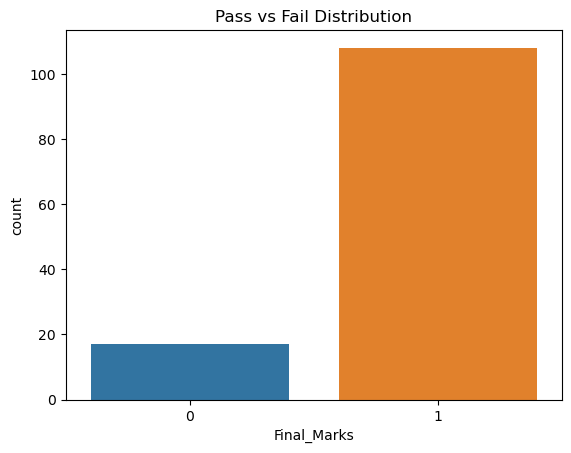

In [31]:
print(df['Final_Marks'].value_counts())

# Visualize Pass/Fail distribution
sns.countplot(x=df['Final_Marks'])
plt.title("Pass vs Fail Distribution")
plt.show()

# 7. Correlation Analysis

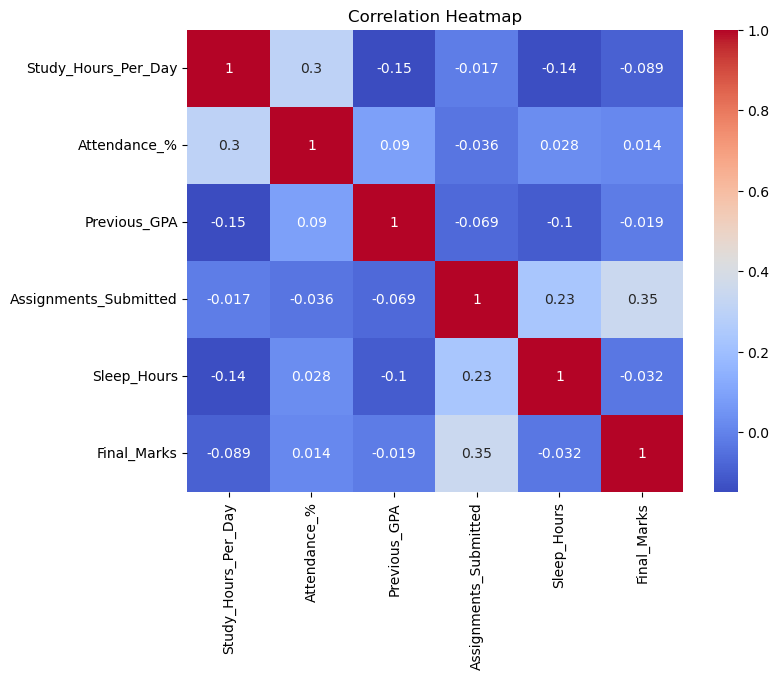

In [32]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


# 8. Separate Features and Target

In [33]:
X = df.drop('Final_Marks', axis=1)
y = df['Final_Marks']



# 9. Identify Numerical and Categorical Columns

In [34]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)



Numerical Columns: Index(['Study_Hours_Per_Day', 'Attendance_%', 'Previous_GPA',
       'Assignments_Submitted', 'Sleep_Hours'],
      dtype='object')
Categorical Columns: Index([], dtype='object')


# 10. Numerical Pipeline

In [35]:
# Handle missing values
# Apply transformation
# Scale numerical features

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('power_transform', PowerTransformer()),
    ('scaler', StandardScaler())
])

# 11. Categorical Pipeline

In [36]:
# Handle missing values
# Encode categorical features

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])


# 12. Column Transformer

In [37]:
# Combine numerical + categorical preprocessing

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])


# 13. Train Test Split

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 14. Create Full ML Pipelines

In [39]:
# Logistic Regression Pipeline
lr_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression())
])

In [40]:
# Random Forest Pipeline
rf_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier())
])

In [41]:
# SVM Pipeline
svm_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', SVC())
])


In [42]:
# KNN Pipeline
knn_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', KNeighborsClassifier())
])

# 15. Train and Compare Models

In [43]:
models = {
    "Logistic Regression": lr_pipeline,
    "Random Forest": rf_pipeline,
    "SVM": svm_pipeline,
    "KNN": knn_pipeline
}

best_accuracy = 0
best_model = None
best_model_name = ""

for name, model in models.items():
    
    # Train model
    model.fit(X_train, y_train)
    
    # Predictions
    predictions = model.predict(X_test)
    
    # Accuracy
    accuracy = accuracy_score(y_test, predictions)
    
    print(f"\n{name}")
    print("Accuracy:", accuracy)
    print(classification_report(y_test, predictions))
    print("-"*50)
    
    # Save best model
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model
        best_model_name = name



Logistic Regression
Accuracy: 0.84
              precision    recall  f1-score   support

           0       0.33      0.33      0.33         3
           1       0.91      0.91      0.91        22

    accuracy                           0.84        25
   macro avg       0.62      0.62      0.62        25
weighted avg       0.84      0.84      0.84        25

--------------------------------------------------

Random Forest
Accuracy: 0.92
              precision    recall  f1-score   support

           0       1.00      0.33      0.50         3
           1       0.92      1.00      0.96        22

    accuracy                           0.92        25
   macro avg       0.96      0.67      0.73        25
weighted avg       0.93      0.92      0.90        25

--------------------------------------------------

SVM
Accuracy: 0.88
              precision    recall  f1-score   support

           0       0.50      0.33      0.40         3
           1       0.91      0.95      0.93      

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


# 16. Best Model Result

In [44]:
print("\nBest Model:", best_model_name)
print("Best Accuracy:", best_accuracy)




Best Model: Random Forest
Best Accuracy: 0.92


# 17. Confusion Matrix

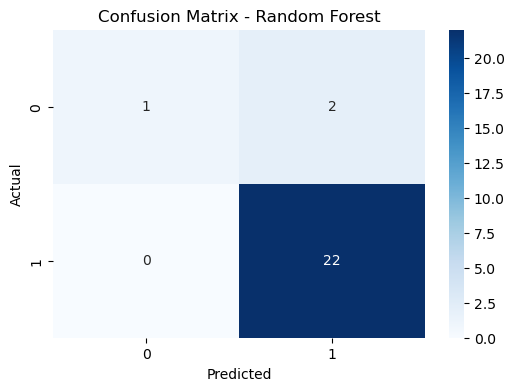

In [45]:
best_predictions = best_model.predict(X_test)

cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# 18. Save Final Pipeline Model

In [46]:
joblib.dump(best_model, "student_pass_fail_pipeline.pkl")

print("Final Pipeline Model Saved Successfully!")

Final Pipeline Model Saved Successfully!


# 19. Load Saved Model

In [47]:
loaded_model = joblib.load("student_pass_fail_pipeline.pkl")

# 20. Prediction Function

In [49]:
def predict_student_result():
    
    print("\nEnter Student Details:")
    
    # User inputs
    study_hours = float(input("Enter Study Hours Per Day: "))
    attendance = float(input("Enter Attendance Percentage: "))
    previous_gpa = float(input("Enter Previous GPA: "))
    assignments = float(input("Enter Assignments Submitted: "))
    sleep_hours = float(input("Enter Sleep Hours: "))
    
    # Create dataframe for prediction
    new_data = pd.DataFrame({
        'Study_Hours_Per_Day': [study_hours],
        'Attendance_%': [attendance],
        'Previous_GPA': [previous_gpa],
        'Assignments_Submitted': [assignments],
        'Sleep_Hours': [sleep_hours]
    })
    
    # Predict
    prediction = loaded_model.predict(new_data)
    
    # Output result
    if prediction[0] == 1:
        print("\nPrediction Result: Student will PASS ✅")
    else:
        print("\nPrediction Result: Student will FAIL ❌")



# Call Function


predict_student_result()


Enter Student Details:
Enter Study Hours Per Day: 1
Enter Attendance Percentage: 23
Enter Previous GPA: 2
Enter Assignments Submitted: 1
Enter Sleep Hours: 12

Prediction Result: Student will FAIL ❌
